In [1]:
import pandas as pd

In [2]:
data_info = pd.read_csv('application_info.csv')
data_target = pd.read_csv('default_flg.csv')

In [3]:
data = pd.merge(data_info, data_target, on='id', how='inner')

In [4]:
data.head()

,id,application_dt,sample_cd,education_cd,gender_cd,age,car_own_flg,car_type_flg,appl_rej_cnt,good_work_flg,Score_bki,out_request_cnt,region_rating,home_address_cd,work_address_cd,income,SNA,first_time_cd,Air_flg,default_flg
0,1,01JAN2014,train,SCH,M,27,Y,Y,0,0,-1.917831,0,40,2,3,32000,1,4,N,0
1,2,01JAN2014,train,GRD,F,26,N,N,0,0,-1.153144,2,60,2,3,50000,2,1,N,0
2,3,01JAN2014,train,SCH,M,35,N,N,0,1,-1.732810,0,40,1,2,20000,4,3,N,0
3,4,01JAN2014,train,GRD,F,35,N,N,0,1,-2.552133,2,20,2,3,80000,1,3,N,0
4,5,01JAN2014,train,UGR,F,24,N,N,0,0,-1.914581,1,50,2,3,27000,1,2,N,0


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180816 entries, 0 to 180815
Data columns (total 20 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   id               180816 non-null  int64  
 1   application_dt   180816 non-null  object 
 2   sample_cd        180816 non-null  object 
 3   education_cd     180093 non-null  object 
 4   gender_cd        180816 non-null  object 
 5   age              180816 non-null  int64  
 6   car_own_flg      180816 non-null  object 
 7   car_type_flg     180816 non-null  object 
 8   appl_rej_cnt     180816 non-null  int64  
 9   good_work_flg    180816 non-null  int64  
 10  Score_bki        180816 non-null  float64
 11  out_request_cnt  180816 non-null  int64  
 12  region_rating    180816 non-null  int64  
 13  home_address_cd  180816 non-null  int64  
 14  work_address_cd  180816 non-null  int64  
 15  income           180816 non-null  int64  
 16  SNA              180816 non-null  int6

In [6]:
data['default_flg'].value_counts(normalize=True)

default_flg
0    0.884778
1    0.115222
Name: proportion, dtype: float64

In [7]:
data = data.dropna()

In [8]:
data.groupby("education_cd")["default_flg"].mean()

education_cd
ACD    0.043651
GRD    0.079645
PGR    0.051290
SCH    0.141383
UGR    0.117844
Name: default_flg, dtype: float64

In [9]:
features = ['education_cd', 'gender_cd', 'age', 'car_own_flg', 'good_work_flg', 'income', 'default_flg']

In [10]:
data = data[features]

In [11]:
data.head()

,education_cd,gender_cd,age,car_own_flg,good_work_flg,income,default_flg
0,SCH,M,27,Y,0,32000,0
1,GRD,F,26,N,0,50000,0
2,SCH,M,35,N,1,20000,0
3,GRD,F,35,N,1,80000,0
4,UGR,F,24,N,0,27000,0


In [12]:
data['higher_education'] = data['education_cd'].isin(['GRD', 'PGR', 'ACD']).astype(int)

In [13]:
data = data.drop(columns=['education_cd'])

In [14]:
data['gender_cd'] = data['gender_cd'].map({'M': 1, 'F': 0})
data['car_own_flg'] = data['car_own_flg'].map({'Y': 1, 'N': 0})

In [15]:
data.head()

,gender_cd,age,car_own_flg,good_work_flg,income,default_flg,higher_education
0,1,27,1,0,32000,0,0
1,0,26,0,0,50000,0,1
2,1,35,0,1,20000,0,0
3,0,35,0,1,80000,0,1
4,0,24,0,0,27000,0,0


In [19]:
corr = data.corr()

In [20]:
corr['default_flg'].sort_values()

higher_education   -0.087504
good_work_flg      -0.047580
income             -0.040780
car_own_flg        -0.035814
age                -0.026053
gender_cd           0.020315
default_flg         1.000000
Name: default_flg, dtype: float64

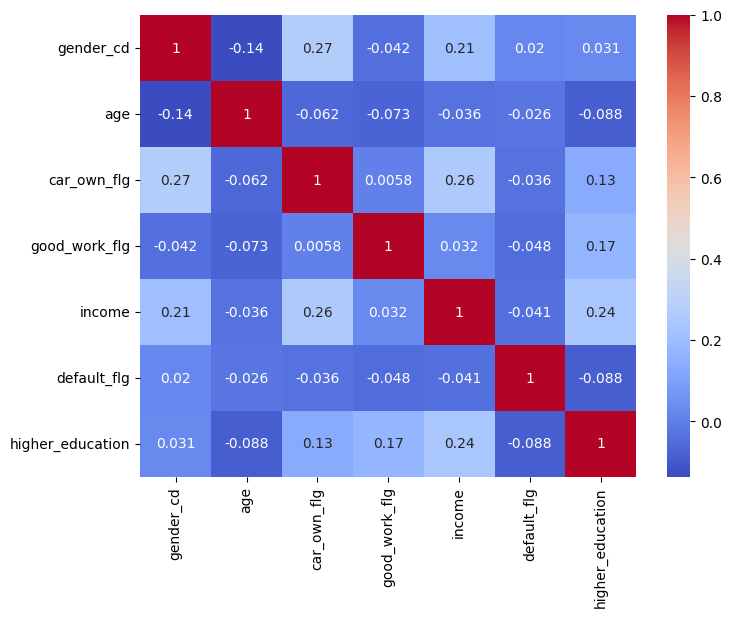

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.show()

In [16]:
from sklearn.model_selection import train_test_split

In [17]:
X = data.drop(columns=['default_flg'])
y = data['default_flg']


In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(144074, 6) (36019, 6)
(144074,) (36019,)


In [23]:
y.value_counts(normalize=True)

default_flg
0    0.884748
1    0.115252
Name: proportion, dtype: float64

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) 

In [25]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(class_weight='balanced', max_iter=1000)
model_lr.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [26]:
y_proba = model_lr.predict_proba(X_test_scaled)[:, 1]

In [27]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_proba)
print(roc_auc)

0.5982301889899546


In [28]:
coef = pd.Series(model_lr.coef_[0], index=X.columns)
coef.sort_values()

higher_education   -0.261848
good_work_flg      -0.125103
age                -0.103903
car_own_flg        -0.102600
income             -0.084872
gender_cd           0.097013
dtype: float64

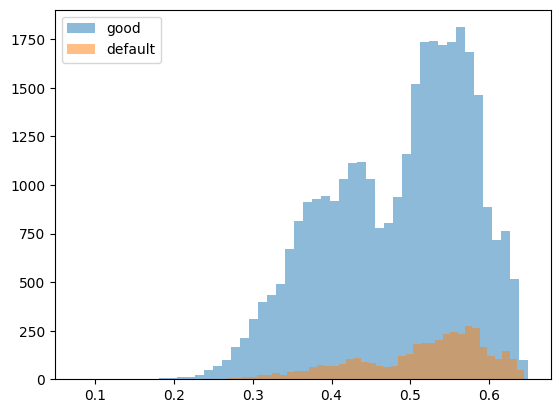

In [29]:
import matplotlib.pyplot as plt

plt.hist(y_proba[y_test == 0], bins=50, alpha=0.5, label="good")
plt.hist(y_proba[y_test == 1], bins=50, alpha=0.5, label="default")
plt.legend()
plt.show()

In [39]:
porog = 0.5
y_pred = (y_proba >= porog).astype(int)

In [40]:
from sklearn.metrics import precision_score, recall_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f'Precision = {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'Denied: {y_pred.mean()*100:0.1f}%')


Precision = 0.14
Recall: 0.66
Denied: 53.4%


66% реальных дефолтов нашла

14% реальных дефолтов среди всех, кому сказала что будет дефолт (точность отказов)

In [44]:
for t in [0.2, 0.3, 0.4, 0.5, 0.6]:
    y_pred = (y_proba >= t).astype(int)

    p = precision_score(y_test, y_pred)
    r = recall_score(y_test, y_pred)

    print(f"porog={t:.1f}  precision={p:.2f}  recall={r:.2f}  denied={y_pred.mean()*100:.1f}%")

porog=0.2  precision=0.12  recall=1.00  denied=99.9%
porog=0.3  precision=0.12  recall=0.99  denied=97.7%
porog=0.4  precision=0.13  recall=0.88  denied=79.9%
porog=0.5  precision=0.14  recall=0.66  denied=53.4%
porog=0.6  precision=0.17  recall=0.12  denied=7.8%


# Grad Boost

In [46]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, precision_score, recall_score
from sklearn.utils.class_weight import compute_sample_weight

weights = compute_sample_weight(class_weight='balanced', y=y_train)

model_gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42)


In [47]:
model_gb.fit(X_train, y_train, sample_weight=weights)

,loss,'log_loss'
,learning_rate,0.05
,n_estimators,200
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [49]:
y_proba_gb = model_gb.predict_proba(X_test)[:,1]

In [50]:
roc_auc_gb = roc_auc_score(y_test, y_proba_gb)
print(f'ROC AUC: {roc_auc_gb:.2f}')

ROC AUC: 0.61


In [53]:
porog = 0.5
y_pred_gb = (y_proba_gb >= porog).astype(int)

print(f"Precision: {precision_score(y_test, y_pred_gb):.2f}")
print(f"Recall: {recall_score(y_test, y_pred_gb):.2f}")
print(f"Denied: {y_pred_gb.mean() * 100:.1f}%")

Precision: 0.15
Recall: 0.65
Denied: 51.4%


In [54]:
for t in [0.2, 0.3, 0.4, 0.5, 0.6]:
    y_pred_gb = (y_proba_gb >= t).astype(int)

    p = precision_score(y_test, y_pred_gb)
    r = recall_score(y_test, y_pred_gb)

    print(f"porog={t:.1f}  precision={p:.2f}  recall={r:.2f}  denied={y_pred_gb.mean()*100:.1f}%")

porog=0.2  precision=0.12  recall=1.00  denied=99.6%
porog=0.3  precision=0.12  recall=0.98  denied=96.0%
porog=0.4  precision=0.13  recall=0.89  denied=80.2%
porog=0.5  precision=0.15  recall=0.65  denied=51.4%
porog=0.6  precision=0.18  recall=0.17  denied=10.5%


In [55]:
import pandas as pd

importances = pd.Series(
    model_gb.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importances)

higher_education    0.464983
income              0.205931
age                 0.137741
good_work_flg       0.078441
gender_cd           0.072256
car_own_flg         0.040648
dtype: float64


In [56]:
import joblib

joblib.dump(model_gb, "credit_model_gb.pkl")
# joblib.dump(scaler, "scaler.pkl")

['credit_model_gb.pkl']